# La huella humana en las mareas: 25 ríos cambiados

> **El mar sube. Lo sabemos.** Pero las mareas, dentro de los ríos que conectan al mar, hicieron algo que casi nadie miraba: cambiaron mucho más, y donde no las estábamos buscando.

---

**Paper:** *Human footprint on estuarine tidal hydrodynamics* — Beemster et al. (2026), *Nature Geoscience*
**DOI:** [10.1038/s41561-026-01969-4](https://doi.org/10.1038/s41561-026-01969-4)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-27-mareas-estuarios-huella-humana/notebook.ipynb)

## Qué hicieron

El equipo recopiló registros históricos y modernos de **25 estuarios** en 9 países —desde el Yangtze hasta el Hudson, pasando por el Sena y el Elba— y comparó cómo se comportan las mareas hoy frente a hace un siglo o más.

Para cada estuario midieron tres cosas:

1. **Rango de marea máximo** (la diferencia entre pleamar y bajamar) — ¿cuánto cambió?
2. **Velocidad de propagación de la onda** (qué tan rápido viaja la marea río arriba)
3. **Dónde** ocurre ese cambio máximo —en la boca, a 50 km, a 200 km tierra adentro—

Y cruzaron todo con un inventario de **233 intervenciones humanas** documentadas: dragados, rellenos, esclusas, embalses.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
FUENTE = 'Fuente: Beemster et al. (2026), Nature Geoscience | Datos: Tablas S1–S2 + sources.xlsx (MOESMs)'
COLOR_AMPLIFICA = '#DC2626'   # rojo — marea creció
COLOR_ATENUA    = '#2563EB'   # azul — marea bajó
COLOR_NEUTRO    = '#BBBBBB'   # gris — referencia
COLOR_INTERV    = '#7C3AED'   # violeta — intervenciones
COLOR_INLAND    = '#059669'   # esmeralda — distancia tierra adentro

# Setup
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Estilo CaM
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga de datos
estuarios = pd.read_csv('datos/estuarios.csv')
intervenciones = pd.read_csv('datos/intervenciones.csv')
resumen = pd.read_csv('datos/intervenciones_resumen.csv')

print(f'Estuarios analizados: {len(estuarios)}')
print(f'Países representados: {estuarios["country"].nunique()}')
print(f'Total intervenciones inventariadas: {intervenciones.shape[0]}')
print(f'Tipos de intervención distintos: {resumen.shape[0]}')

Estuarios analizados: 25
Países representados: 9
Total intervenciones inventariadas: 233
Tipos de intervención distintos: 11


## Aquí está.

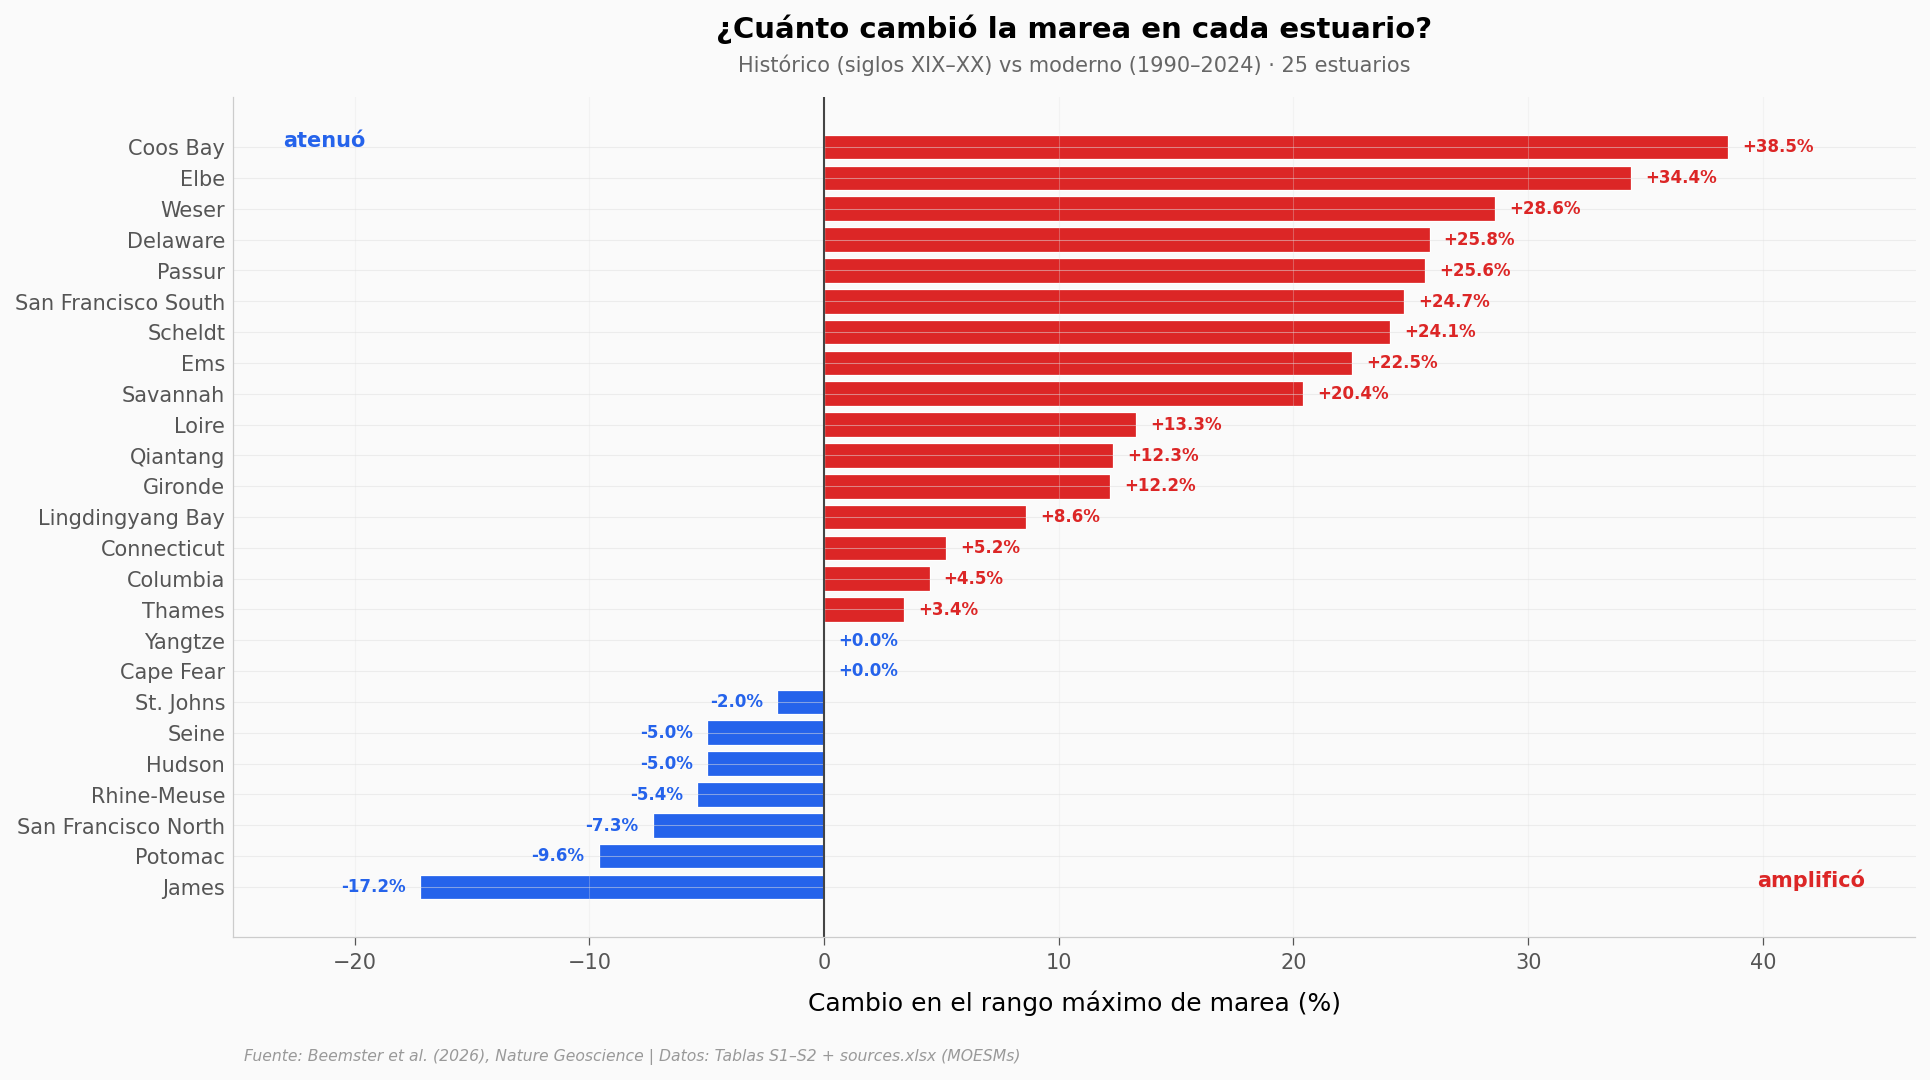

In [2]:
df = estuarios.copy()
df = df.sort_values('maxtr_chg_pct')
colores = [COLOR_AMPLIFICA if v > 0 else COLOR_ATENUA for v in df['maxtr_chg_pct']]

fig, ax = plt.subplots(figsize=(13, 7))
ax.barh(df['estuary'], df['maxtr_chg_pct'], color=colores, edgecolor='white', linewidth=0.6)
ax.axvline(0, color='#444444', linewidth=1.0)

# Etiquetas con porcentaje a la derecha de cada barra
for i, (e, v) in enumerate(zip(df['estuary'], df['maxtr_chg_pct'])):
    ha = 'left' if v >= 0 else 'right'
    offset = 0.6 if v >= 0 else -0.6
    color_txt = colores[i]
    ax.text(v + offset, i, f'{v:+.1f}%', va='center', ha=ha,
            fontsize=8, color=color_txt, fontweight='bold')

ax.set_xlabel('Cambio en el rango máximo de marea (%)')
ax.set_title('¿Cuánto cambió la marea en cada estuario?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Histórico (siglos XIX–XX) vs moderno (1990–2024) · 25 estuarios',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Inline labels (reemplazan legend box)
ax.text(0.97, 0.06, 'amplificó',
        transform=ax.transAxes, fontsize=10, color=COLOR_AMPLIFICA,
        fontweight='bold', ha='right')
ax.text(0.03, 0.94, 'atenuó',
        transform=ax.transAxes, fontsize=10, color=COLOR_ATENUA,
        fontweight='bold', ha='left')

ax.grid(axis='x', alpha=0.3)
ax.set_xlim(df['maxtr_chg_pct'].min() - 8, df['maxtr_chg_pct'].max() + 8)
fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/cambio_tr_por_estuario.png', dpi=200, bbox_inches='tight')
plt.show()

**Lo que llama la atención:**

- **16 de 25 estuarios amplificaron** su rango máximo de marea. El cambio medio del rango de marea es +10,1% y la mediana +8,6% —el rango va desde +38,5% (Coos Bay, EE. UU.) hasta −17,2% (James, EE. UU.).
- 7 estuarios fueron en sentido contrario (el rango bajó) y 2 quedaron prácticamente sin cambio. No es un patrón uniforme —cada río responde a su mezcla particular de intervenciones.
- El sesgo hacia la amplificación es claro, pero los datos no muestran un solo número limpio. Muestran una distribución.

## Pero la sorpresa real no es **si** cambió. Es **dónde**.

Si el mar sube, uno esperaría que la marea suba primero en la boca del estuario —donde el río se encuentra con el océano. Eso parece intuitivo.

Veamos qué pasó en realidad.

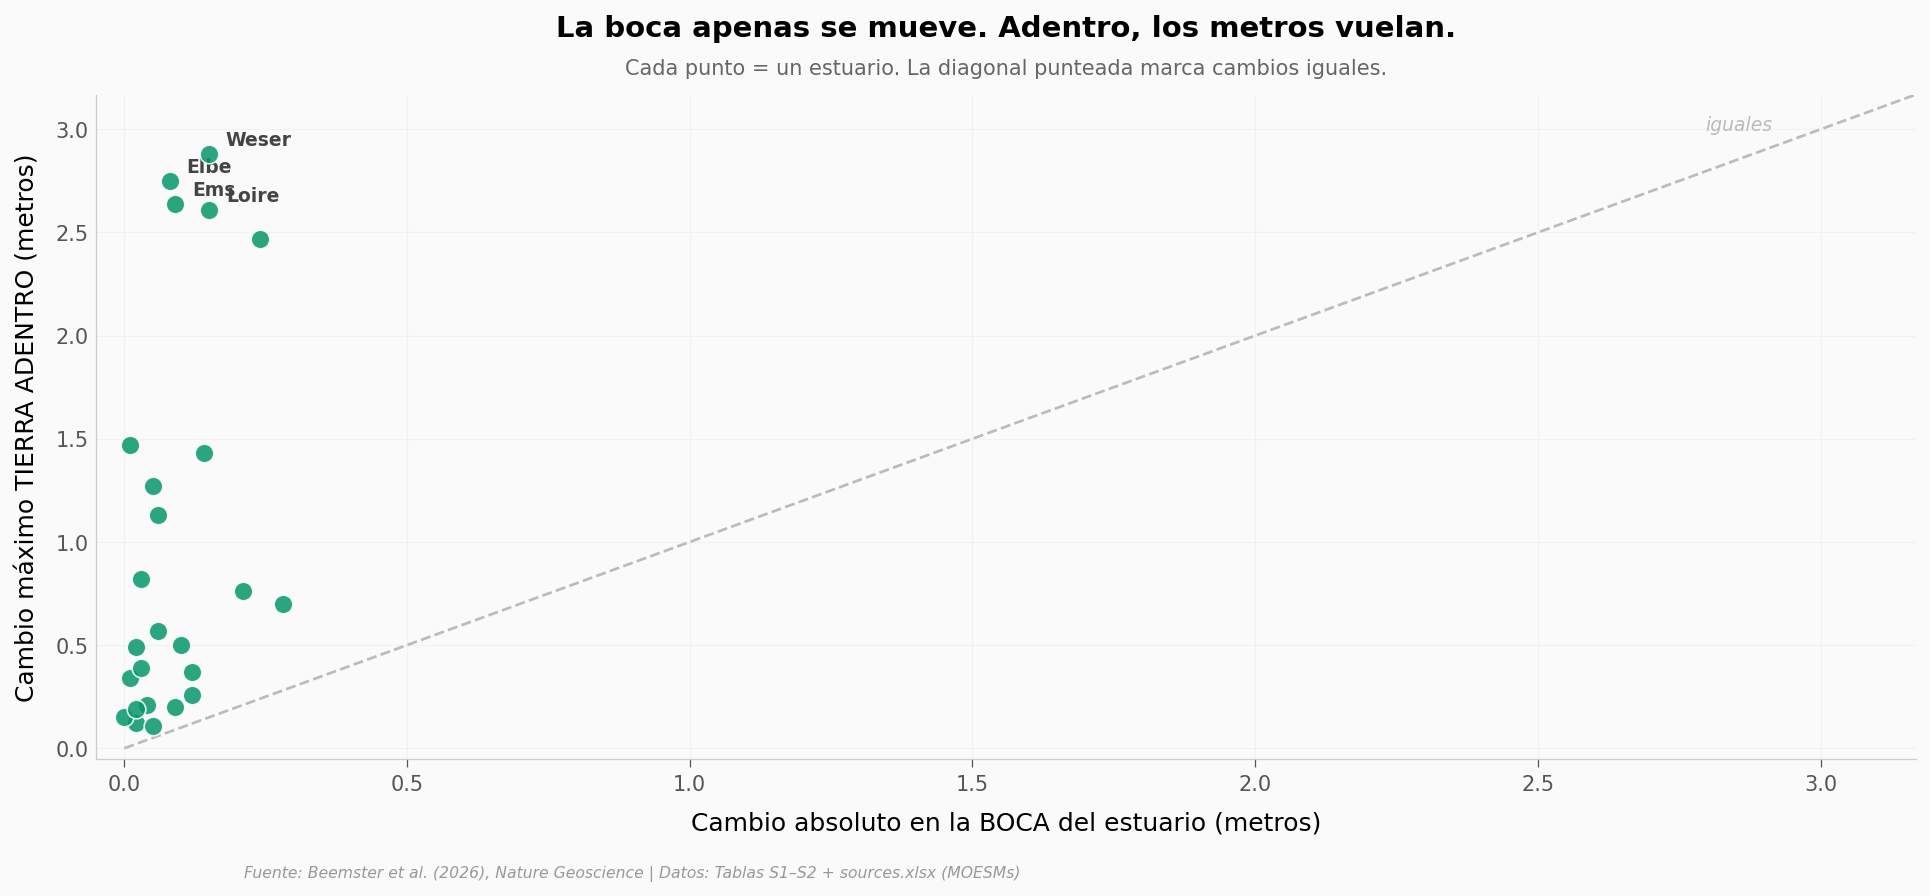

Cambio máximo en la BOCA — mediana: 0.06 m | máximo: 0.28 m
Cambio máximo TIERRA ADENTRO — mediana: 0.57 m | máximo: 2.88 m
Razón mediana adentro/boca: 9.5x


In [3]:
mouth_abs = (estuarios['mouth_m'] - estuarios['mouth_h']).abs()
max_abs   = estuarios['maxchg_tr_chg_m'].abs()

fig, ax = plt.subplots(figsize=(13, 5.8))

# Eje X = mouth change (m), eje Y = max change adentro (m)
sc = ax.scatter(mouth_abs, max_abs,
                color=COLOR_INLAND, s=80, alpha=0.85,
                edgecolors='white', linewidths=0.8, zorder=5)

# Diagonal de igualdad
lim = max(mouth_abs.max(), max_abs.max()) * 1.1
ax.plot([0, lim], [0, lim], color=COLOR_NEUTRO, linewidth=1.3,
        linestyle='--', zorder=2, label='_nolegend_')
ax.text(lim * 0.92, lim * 0.94, 'iguales', fontsize=9,
        color=COLOR_NEUTRO, ha='right', va='bottom', style='italic')

# Etiquetar 4 estuarios extremos
top_idx = max_abs.nlargest(4).index
for i in top_idx:
    name = estuarios.loc[i, 'estuary']
    ax.annotate(name, xy=(mouth_abs[i], max_abs[i]),
                xytext=(8, 4), textcoords='offset points',
                fontsize=9, color='#444444', fontweight='bold')

ax.set_xlabel('Cambio absoluto en la BOCA del estuario (metros)')
ax.set_ylabel('Cambio máximo TIERRA ADENTRO (metros)')
ax.set_title('La boca apenas se mueve. Adentro, los metros vuelan.',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Cada punto = un estuario. La diagonal punteada marca cambios iguales.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_xlim(-0.05, lim)
ax.set_ylim(-0.05, lim)
ax.grid(alpha=0.3)
fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/boca_vs_adentro.png', dpi=200, bbox_inches='tight')
plt.show()

# Resumen numérico para acompañar
print(f'Cambio máximo en la BOCA — mediana: {mouth_abs.median():.2f} m | máximo: {mouth_abs.max():.2f} m')
print(f'Cambio máximo TIERRA ADENTRO — mediana: {max_abs.median():.2f} m | máximo: {max_abs.max():.2f} m')
print(f'Razón mediana adentro/boca: {max_abs.median() / mouth_abs.median():.1f}x')

La mediana del cambio en la boca es 6 cm. La mediana tierra adentro es 57 cm —**casi diez veces más**. Y para algunos estuarios la diferencia es de un orden de magnitud.

Eso responde "**cuánto**". Falta lo más importante: ¿a qué distancia de la boca está ese punto donde la marea cambió?

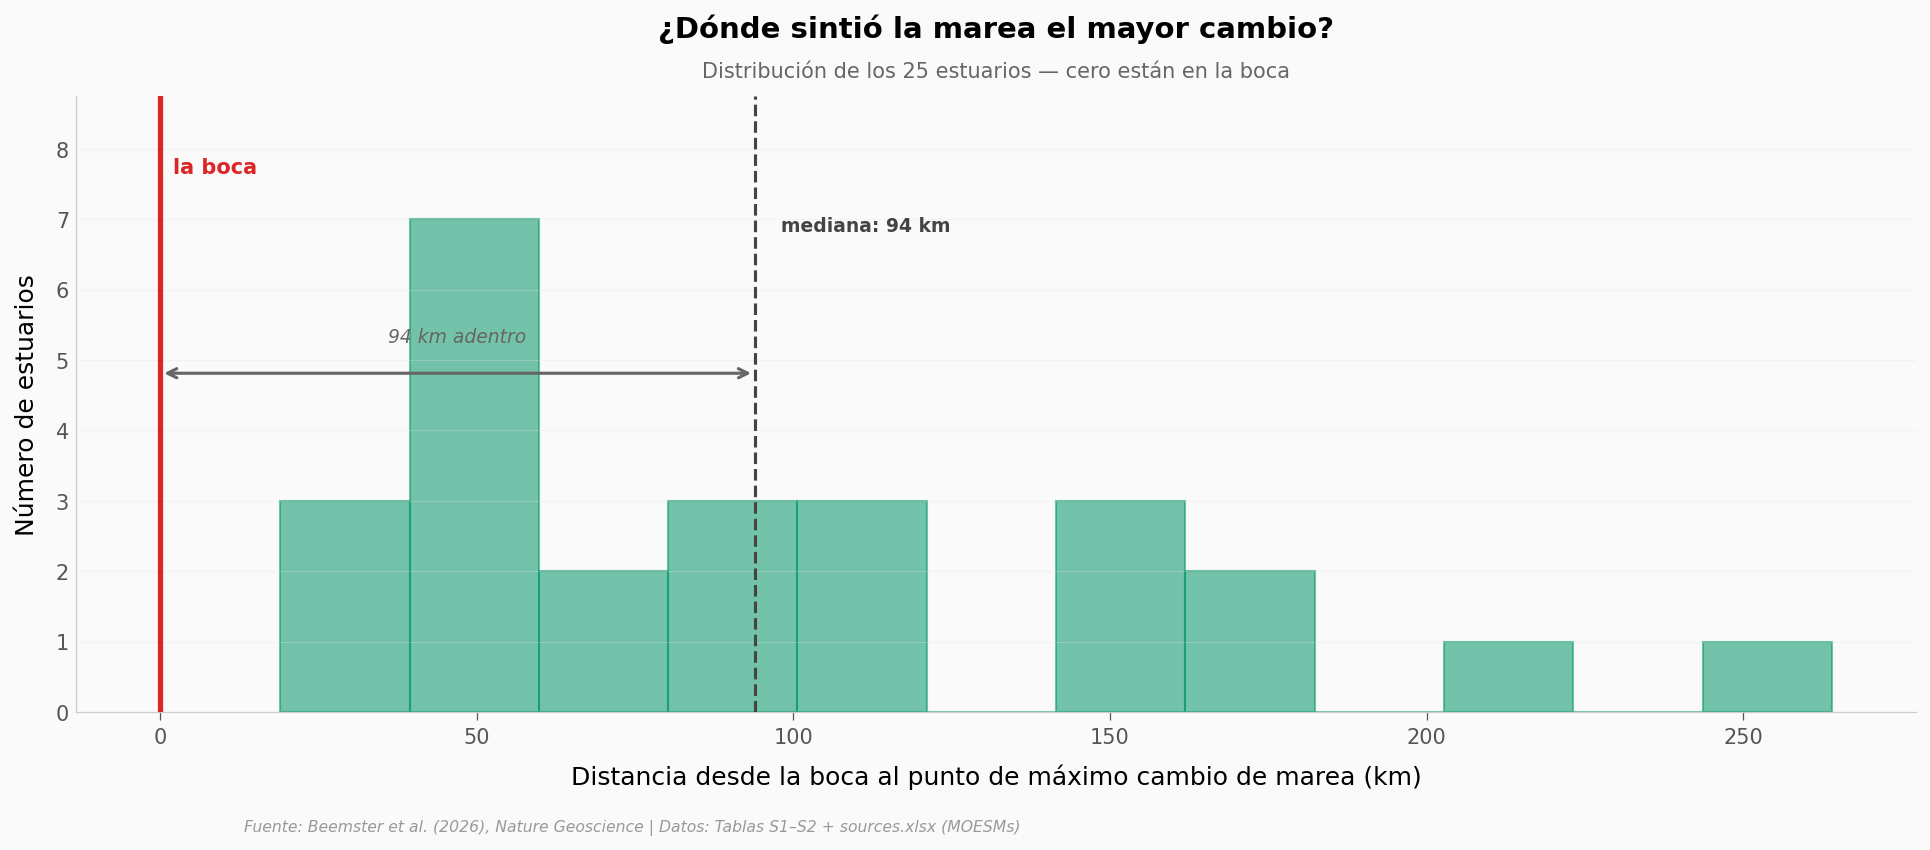

n = 25 estuarios
Mediana: 94 km · Media: 99 km · IQR: [55, 147] km
A más de 50 km tierra adentro: 20 de 25
A más de 100 km: 10 de 25
En la boca exacta (0 km): 0 de 25


In [4]:
loc = estuarios['loc_max_chg_km'].dropna()

fig, ax = plt.subplots(figsize=(13, 5.5))
n, bins, patches = ax.hist(loc, bins=12, color=COLOR_INLAND, alpha=0.55,
                           edgecolor=COLOR_INLAND, linewidth=1.0)
y_max = n.max() * 1.25
ax.set_ylim(0, y_max)

# Línea en 0 km = la boca
ax.axvline(0, color=COLOR_AMPLIFICA, linewidth=2.5, zorder=10)
ax.text(2, y_max * 0.9, 'la boca', color=COLOR_AMPLIFICA,
        fontsize=10, fontweight='bold', ha='left', va='top')

# Línea en mediana
mediana = loc.median()
ax.axvline(mediana, color='#444444', linewidth=1.5, linestyle='--', zorder=9)
ax.text(mediana + 4, y_max * 0.78,
        f'mediana: {mediana:.0f} km',
        color='#444444', fontsize=9, fontweight='bold', ha='left')

# Flecha bidireccional desde 0 hasta mediana
ax.annotate('', xy=(mediana, y_max * 0.55), xytext=(0, y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(mediana / 2, y_max * 0.6, f'{mediana:.0f} km adentro',
        ha='center', fontsize=9, color='#666666', style='italic')

ax.set_xlabel('Distancia desde la boca al punto de máximo cambio de marea (km)')
ax.set_ylabel('Número de estuarios')
ax.set_title('¿Dónde sintió la marea el mayor cambio?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Distribución de los 25 estuarios — cero están en la boca',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.grid(axis='y', alpha=0.3)
fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/distancia_max_cambio.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'n = {len(loc)} estuarios')
print(f'Mediana: {loc.median():.0f} km · Media: {loc.mean():.0f} km · IQR: [{loc.quantile(.25):.0f}, {loc.quantile(.75):.0f}] km')
print(f'A más de 50 km tierra adentro: {(loc > 50).sum()} de {len(loc)}')
print(f'A más de 100 km: {(loc > 100).sum()} de {len(loc)}')
print(f'En la boca exacta (0 km): {(loc == 0).sum()} de {len(loc)}')

**Cero estuarios concentran su mayor cambio en la boca.** La mediana está a 94 km tierra adentro. La onda de marea entra al estuario y se transforma en su recorrido —se acelera, se hincha, a veces se atenúa— y donde más cambia es bien lejos del mar.

¿Qué hay 94 km tierra adentro? Casi siempre, intervenciones humanas.

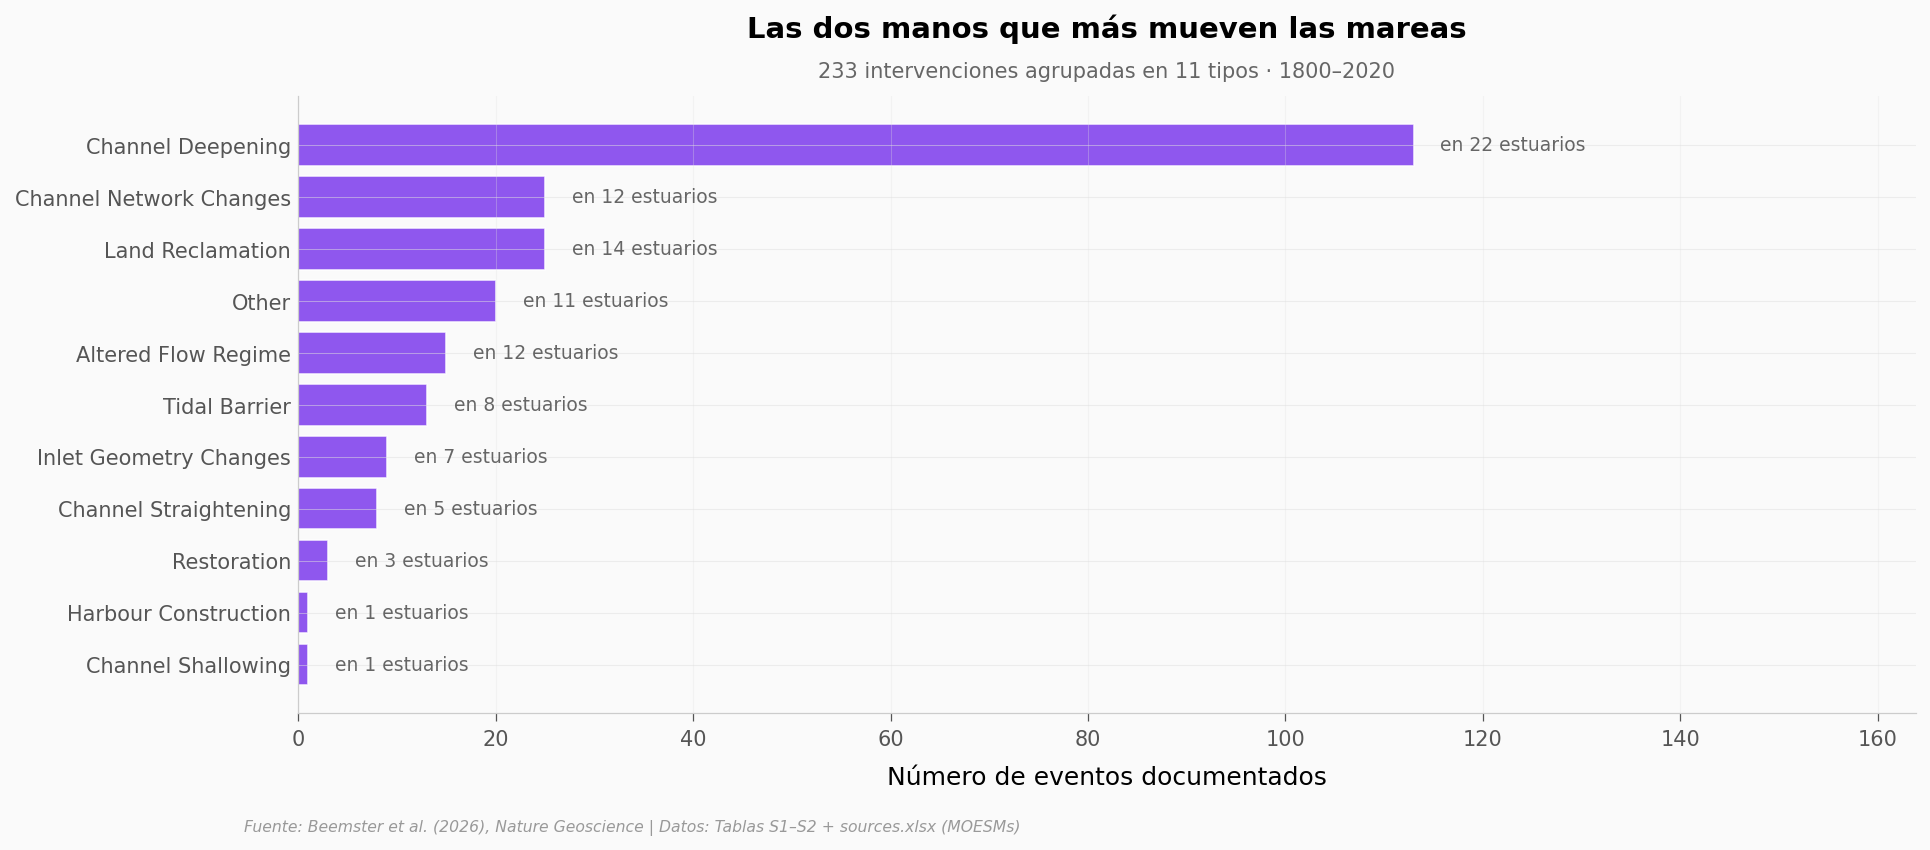

Profundización de canales: 113 eventos · presente en 22 de 25 estuarios (88%)
Recuperación de tierra: 25 eventos · presente en 14 de 25 estuarios (56%)


In [5]:
top = resumen.sort_values('count', ascending=True)

fig, ax = plt.subplots(figsize=(13, 5.5))

ax.barh(top['intervention_type'], top['count'],
        color=COLOR_INTERV, alpha=0.85, edgecolor='white', linewidth=0.8)

# Anotar cuántos estuarios afecta cada tipo a la derecha de la barra
for i, (_, row) in enumerate(top.iterrows()):
    ax.text(row['count'] + 1.5, i,
            f"  en {row['n_estuaries_affected']} estuarios",
            va='center', ha='left', fontsize=9, color='#666666')

ax.set_xlabel('Número de eventos documentados')
ax.set_title('Las dos manos que más mueven las mareas',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        '233 intervenciones agrupadas en 11 tipos · 1800–2020',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_xlim(0, top['count'].max() * 1.45)
ax.grid(axis='x', alpha=0.3)
fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/intervenciones_por_tipo.png', dpi=200, bbox_inches='tight')
plt.show()

ch_dp = resumen.loc[resumen['intervention_type'] == 'Channel Deepening'].iloc[0]
land_re = resumen.loc[resumen['intervention_type'] == 'Land Reclamation'].iloc[0]
print(f'Profundización de canales: {ch_dp["count"]} eventos · presente en {ch_dp["n_estuaries_affected"]} de 25 estuarios ({ch_dp["n_estuaries_affected"]/25*100:.0f}%)')
print(f'Recuperación de tierra: {land_re["count"]} eventos · presente en {land_re["n_estuaries_affected"]} de 25 estuarios ({land_re["n_estuaries_affected"]/25*100:.0f}%)')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| **25 estuarios analizados** | ✅ | El CSV tiene 25 filas; la hoja *Sources* del MOESM2 lista los 25. |
| **La mayoría amplificaron su marea** | ✅ | 16 de 25 con cambio positivo (64%). Mediana +8,6%, media +10,1%, IQR [−2,0%, +24,1%]. |
| **La onda de marea se acelera ~38%** | ⚠️ | El paper reporta +38% (22 de 24 estuarios positivos). Nuestro recálculo da +35% (21 de 24). La diferencia (≈3 puntos porcentuales) probablemente viene de cómo se promedia: el paper enmarca la cifra como aumento promedio entre estuarios con velocidad disponible; nosotros usamos la media simple de los cambios porcentuales. |
| **El cambio máximo NO está en la boca** | ✅ | 0 de 25 estuarios tienen su máximo cambio en `loc_max_chg_km == 0`. Mediana 94 km adentro, IQR [55, 147] km. |
| **Profundización + recuperación de tierra dominan** | ✅ | Profundización: 113 eventos en 22 de 25 estuarios. Recuperación de tierra: 25 eventos en 14 de 25. |
| **Las intervenciones causan los cambios** | ⚠️ | El estudio es **observacional longitudinal** —compara registros históricos con modernos en los mismos sitios, pero no manipula nada. Los autores argumentan causalidad por concordancia temporal, magnitud y ubicación, y el abstract argumenta que las modificaciones antropogénicas tienen la mayor influencia. Los datos son consistentes con esa lectura, pero un diseño observacional no la prueba como un experimento. |

> **Limitaciones honestas:**
> - **n = 25 estuarios.** Es una muestra grande para un trabajo de hidrodinámica histórica, pero pequeña frente al inventario global. Los seleccionados son los que tienen registros centenarios de calidad —probablemente sesgados hacia estuarios industrializados.
> - **Periodos heterogéneos.** El "histórico" varía entre 1825 (Gironde) y los años setenta (Yangtze). El "moderno" cubre 1990–2024. Cualquier promedio cruza épocas distintas.
> - **Sin atribución mecánica directa.** El inventario de intervenciones está espacialmente correlacionado con los cambios; eso es coherente con causalidad pero no la demuestra. Un experimento controlado de un estuario es imposible.

## Ahora tú

Tres preguntas para explorar con los datos:

1. **¿Hay relación entre cuántas intervenciones tiene un estuario y cuánto cambió su marea?**
   Pista: agrupa `intervenciones` por `estuary` y cruza con `maxtr_chg_pct`.

2. **¿Algún tipo de intervención se asocia con cambios mayores que otros?**
   Pista: para cada estuario, mira si tiene `Channel Deepening` o `Land Reclamation`, y compara los cambios con quienes no lo tienen.

3. **¿Por qué Coos Bay y Elbe amplificaron tanto (>34%)?**
   Pista: lista las intervenciones de esos dos estuarios y compáralas con uno que se atenuó (James −17,2%, Potomac −9,6%).

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta: ¿más intervenciones se asocian con mayores cambios de marea?

# Conteo de intervenciones por estuario
conteo = intervenciones.groupby('estuary').size().rename('n_intervenciones').reset_index()

# Cruzar con el cambio porcentual del rango de marea
combinado = estuarios.merge(conteo, on='estuary', how='left').fillna({'n_intervenciones': 0})

# Spearman (regla 33: default para correlaciones, ranks no asume normalidad)
from scipy import stats
mask = combinado[['n_intervenciones', 'maxtr_chg_pct']].notna().all(axis=1)
rho, p = stats.spearmanr(combinado.loc[mask, 'n_intervenciones'],
                         combinado.loc[mask, 'maxtr_chg_pct'].abs())
print(f'Correlación de Spearman entre número de intervenciones y |cambio %|:')
print(f'  rho = {rho:+.3f} · p = {p:.3f} · n = {mask.sum()}')
print()
print('Top 5 estuarios por número de intervenciones:')
print(combinado.nlargest(5, 'n_intervenciones')[['estuary', 'country', 'n_intervenciones', 'maxtr_chg_pct']].to_string(index=False))

Correlación de Spearman entre número de intervenciones y |cambio %|:
  rho = +0.013 · p = 0.951 · n = 25

Top 5 estuarios por número de intervenciones:
    estuary     country  n_intervenciones  maxtr_chg_pct
      Weser     Germany              19.0           28.6
       Elbe     Germany              16.0           34.4
   Columbia         USA              16.0            4.5
        Ems  NL/Germany              15.0           22.5
Rhine-Meuse Netherlands              15.0           -5.4


## Fuentes

**Paper**: [Human footprint on estuarine tidal hydrodynamics](https://doi.org/10.1038/s41561-026-01969-4)  
*Nature Geoscience, 2026-04-24*

**Tablas hidrodinámicas (MOESM1)**: [Supplementary Information](https://static-content.springer.com/esm/art%3A10.1038%2Fs41561-026-01969-4/MediaObjects/41561_2026_1969_MOESM1_ESM.pdf)  
*Tablas S1 y S2 — datos por estuario, periodo histórico vs moderno*

**Inventario de intervenciones (MOESM2)**: [sources.xlsx](https://static-content.springer.com/esm/art%3A10.1038%2Fs41561-026-01969-4/MediaObjects/41561_2026_1969_MOESM2_ESM.xlsx)  
*187 fuentes bibliográficas + 233 intervenciones documentadas*

**Datos derivados**: [4TU.ResearchData](https://doi.org/10.4121/54bf59a6-a827-4d50-a7ad-9f990b5aff89)

*17 afirmaciones verificadas contra estas fuentes.*

---

**Licencia:** CC BY-SA 4.0 · **Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)
**Notebook:** `papers/2026-04-27-mareas-estuarios-huella-humana/notebook.ipynb`